# 2.1. Área bajo restauración

In [1]:
import datetime
now = datetime.datetime.now()
print(f"Última actualización de este notebook: {now.strftime('%d-%m-%Y %H:%M')}")

Última actualización de este notebook: 30-04-2026 16:32


## Metodología de Cálculo

## Fuentes de Datos Utilizadas

Uso de plataforma FERM: su uso no ha sido confirmado por el MMA
Se debe definir qué fuente de información utilizaremos y si se ha sistematizado información en el marco del Plan Nacional de restauración de paisajes: Siembra por Chile lo tiene sistematizado en una base de datos estática; +Bosques lo tiene sistematizado, mas no tengo información de cómo..
 En SIMBIO hay base de datos de iniciativas de restauración que no cuenta con coordenadas ni superficies: esto fue un esfuerzo por compilar información, pero no esta actualizada.
 Catálogo Restauración Ecológica 24-11-2025 1449.xlsx descargada de https://simbio.mma.gob.cl/RestauracionEcologica.

Capa espacial de geoportal tiene polígonos y puntos, sin embargo no está disponible para descarga (https://apps.mma.gob.cl/visorsimbio)

En insumos enviados por PNUD se indica a INFOR o INIA como posibles fuentes. no se menciona GEF.

Se debe desagregar análisis por ecosystem functional groups

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Datos CBD

In [3]:
data_cbd = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_restoration_ecology")
data_cbd

,ID,Restoration approach,Restoration program,Restoration action,Institution,Year,Region,ha,Footnote,Source_link
0,RE-1,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Maule,2319.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
1,RE-2,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Ñuble,1247.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
2,RE-3,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Biobío,2608.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
3,RE-4,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,La Araucanía,2081.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
4,RE-5,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Los Ríos,3574.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
...,...,...,...,...,...,...,...,...,...,...
128,RE-129,Restoration ecology,Other private restoration action,Programa de Restauracion Hidrológica y Foresta...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,314.00,NaN,GEF restauración de paisajes
129,RE-130,Restoration ecology,Other private restoration action,Restauración de microcuencas con presencia de ...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,21.90,NaN,GEF restauración de paisajes
130,RE-131,Restoration ecology,Other private restoration action,Restauración de microcuencas con presencia de ...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,326.70,NaN,GEF restauración de paisajes
131,RE-132,Restoration ecology,SIRSD,SIRSD SAG,SAG,2022,Ñuble,3255.90,Reporte de cofinanciamiento por parte de SIRSD...,GEF restauración de paisajes


In [4]:
# Replace not standard names
data_cbd["Region"] = data_cbd["Region"].replace({
    "Valparaiso": "Valparaíso",
    "Los ríos": "Los Ríos",
    "Los lagos": "Los Lagos",
    "Araucanía": "La Araucanía",
    "Múltiples regiones": "Interregional"
})

### Datos Nacionales

In [5]:
data_ch = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_Landscape restoration")
data_ch = data_ch.drop(15)
data_ch

,ID,Restoration program,Name,Year,Region,Source,ha
0,L-1,GEF Restauración de paisajes,Reserva de la Biosfera Fray Jorge,2023.0,Coquimbo,PRODOC GEF RESTAURACION,134311
1,L-2,GEF Restauración de paisajes,Corredor Bosques de Casablanca – Peñuelas – Qu...,2023.0,Valparaíso,PRODOC GEF RESTAURACION,75916
2,L-3,GEF Restauración de paisajes,Secano Costero – Nilahue (Región de O’Higgins),2023.0,O´Higgins,PRODOC GEF RESTAURACION,122947
3,L-4,GEF Restauración de paisajes,Curepto – Putú – Huenchullamí – Río Maule (Reg...,2023.0,Maule,PRODOC GEF RESTAURACION,150543
4,L-5,GEF Restauración de paisajes,Secano Interior – Altos de Ninhue (Región de Ñ...,2023.0,Ñuble,PRODOC GEF RESTAURACION,30633
5,L-6,GEF Restauración de paisajes,Cayumanque,2023.0,Ñuble,PRODOC GEF RESTAURACION,126168
6,L-7,GEF Restauración de paisajes,Nahuelbuta – Lanalhue,2023.0,Biobío,PRODOC GEF RESTAURACION,73232
7,L-8,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Reforzamiento...,2025.0,Biobío,NaN,1000
8,L-9,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Absorber CO2 ...,2025.0,Biobío,NaN,1000
9,L-10,Otros instrumentos de planificación a escala d...,Plan de Ordenamiento y Gestión Territorial par...,2018.0,Biobío,https://prela.mma.gob.cl/wp-content/uploads/Re...,36956


In [6]:
# Replace not standard names
data_ch["Region"] = data_ch["Region"].replace({
    "O´Higgins": "O'Higgins",
})

## Capa 2: Análisis y síntesis

### Datos CBD

In [7]:
data_region_cbd = data_cbd.groupby('Region')['ha'].sum().reset_index()
data_region_cbd

,Region,ha
0,Antofagasta,261.000
1,Arica y Parinacota,3068.000
2,Atacama,158.000
3,Aysén,19168.000
4,Biobío,4205.504
5,Coquimbo,3100.530
6,Interregional,62974.000
7,La Araucanía,5563.800
8,Los Lagos,5979.020
9,Los Ríos,8809.000


In [8]:
print(f"Hectáreas totales {data_region_cbd['ha'].sum():.2f} ha")

Hectáreas totales 138270.81 ha


In [9]:
list(data_region_cbd["Region"])

['Antofagasta',
 'Arica y Parinacota',
 'Atacama',
 'Aysén',
 'Biobío',
 'Coquimbo',
 'Interregional',
 'La Araucanía',
 'Los Lagos',
 'Los Ríos',
 'Magallanes',
 'Maule',
 'Metropolitana',
 "O'Higgins",
 'Tarapacá',
 'Valparaíso',
 'Ñuble']

In [10]:
region_order = [
    'Arica y Parinacota',
    'Tarapacá',
    'Antofagasta',
    'Atacama',
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Ñuble',
    'Biobío',
    'La Araucanía',
    'Los Ríos',
    'Los Lagos',
    'Aysén',
    'Magallanes',
    'Interregional',
]

In [11]:
data_region_cbd["Region"] = pd.Categorical(data_region_cbd["Region"],
                                           categories=region_order,
                                           ordered=True)
data_region_cbd.sort_values("Region", inplace=True)
data_region_cbd

,Region,ha
1,Arica y Parinacota,3068.000
14,Tarapacá,306.000
0,Antofagasta,261.000
2,Atacama,158.000
5,Coquimbo,3100.530
15,Valparaíso,2462.400
12,Metropolitana,692.226
13,O'Higgins,8162.640
11,Maule,6295.590
16,Ñuble,6006.100


In [12]:
region_count = len(data_region_cbd)
sorted_region_ha = data_region_cbd.sort_values("ha")
first_cut = sorted_region_ha.iloc[region_count - 2]["ha"]
second_cut = sorted_region_ha.iloc[region_count - 1]["ha"]
sorted_region_ha

,Region,ha
2,Atacama,158.000
0,Antofagasta,261.000
14,Tarapacá,306.000
12,Metropolitana,692.226
10,Magallanes,1059.000
15,Valparaíso,2462.400
1,Arica y Parinacota,3068.000
5,Coquimbo,3100.530
4,Biobío,4205.504
7,La Araucanía,5563.800


### Datos Nacionales

In [13]:
data_region_ch = data_ch.groupby('Region')['ha'].sum().reset_index()
data_region_ch

,Region,ha
0,Biobío,250388
1,Coquimbo,134311
2,Los Lagos,217936
3,Maule,150543
4,Metropolitana,84353
5,O'Higgins,122947
6,Valparaíso,75916
7,Ñuble,156801


In [14]:
print(f"Hectáreas totales {data_region_ch['ha'].sum():.2f} ha")

Hectáreas totales 1193195.00 ha


In [15]:
data_region_ch["Region"] = pd.Categorical(data_region_ch["Region"],
                                          categories=region_order,
                                          ordered=True)
data_region_ch.sort_values("Region", inplace=True)
data_region_ch

,Region,ha
1,Coquimbo,134311
6,Valparaíso,75916
4,Metropolitana,84353
5,O'Higgins,122947
3,Maule,150543
7,Ñuble,156801
0,Biobío,250388
2,Los Lagos,217936


## Capa 3: Reporte Digital

### Datos CBD

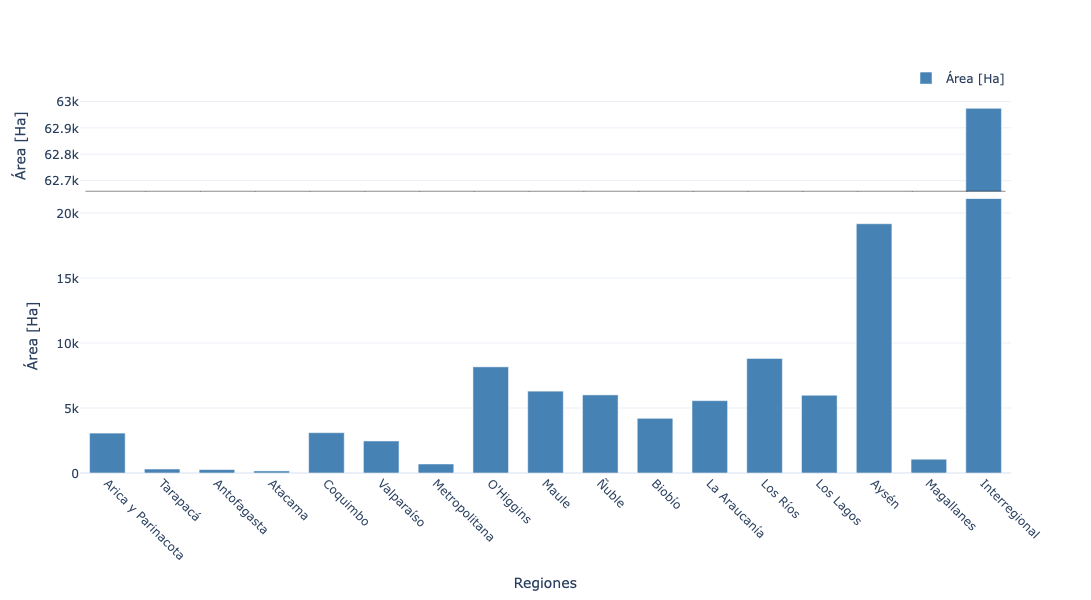

In [16]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    row_heights=[1, 3]  # equivalent to height_ratios
)

position = np.arange(len(data_region_cbd))

# Add bars to both subplots
fig.add_trace(
    go.Bar(
        x=position,
        y=data_region_cbd["ha"],
        name="Área [Ha]",
        marker_color="steelblue",
        showlegend=True
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=position,
        y=data_region_cbd["ha"],
        name="Área [Ha]",
        marker_color="steelblue",
        showlegend=False  # Hide duplicate legend
    ),
    row=2, col=1
)

# Set different y-axis ranges for the break effect
fig.update_yaxes(
    range=[second_cut * (1 - 5e-3), second_cut * (1 + 5e-4)],
    row=1, col=1,
    title_text="Área [Ha]"
)

fig.update_yaxes(
    range=[0, first_cut * 1.1],
    row=2, col=1,
    title_text="Área [Ha]"
)

# Update x-axis
fig.update_xaxes(
    tickvals=position,
    ticktext=data_region_cbd["Region"],
    tickangle=45,
    title_text="Regiones",
    row=2, col=1
)

# Hide x-axis labels on top subplot
fig.update_xaxes(showticklabels=False, row=1, col=1)

# Update layout
fig.update_layout(
    width=800,
    height=600,
    bargap=0.35,  # equivalent to width parameter
    template="plotly_white",
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Add break indicators (diagonal lines) using shapes
# Top subplot - bottom break mark
fig.add_shape(
    type="line",
    x0=-0.4, y0=second_cut * (1 - 5e-3),
    x1=len(data_region_cbd) - 0.6, y1=second_cut * (1 - 5e-3),
    line=dict(color="black", width=1),
    row=1, col=1
)

# Add diagonal break marks
for i in range(len(data_region_cbd) - 1):
    # Top subplot diagonals
    fig.add_shape(
        type="line",
        x0=i + 0.5, y0=second_cut * (1 - 5e-3) - (second_cut * 5e-3),
        x1=i + 0.7, y1=second_cut * (1 - 5e-3),
        line=dict(color="black", width=1),
        row=1, col=1
    )

fig.show()

In [17]:
data_time_cbd = data_cbd.groupby('Year')['ha'].sum().reset_index()
data_time_cbd['ha (cumulative)'] = data_time_cbd['ha'].cumsum()
# data_time_cbd = data_time_cbd.drop(4)
# data_time_cbd["Year"] = data_time_cbd["Year"].astype(int)
data_time_cbd

,Year,ha,ha (cumulative)
0,2022,14537.90,14537.90
1,2023,16237.00,30774.90
2,2024,10640.00,41414.90
3,2025,25622.98,67037.88
4,Sin información precisa,71232.93,138270.81


Debido a presencia de datos sin año (`Sin información precisa`), se omite el gráfico de tiempo para datos CBD.

```python
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time_cbd["Year"], data_time_cbd["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 0.34, data_time_cbd["ha (cumulative)"][3], f'{data_time_cbd["ha (cumulative)"][3]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time_cbd["Year"])
ax.set_xticklabels(data_time_cbd["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time_cbd["Year"], data_time_cbd["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.tight_layout()
fig.savefig("years_cbd.png")
plt.show()
plt.close(fig)
```


### Datos Nacionales

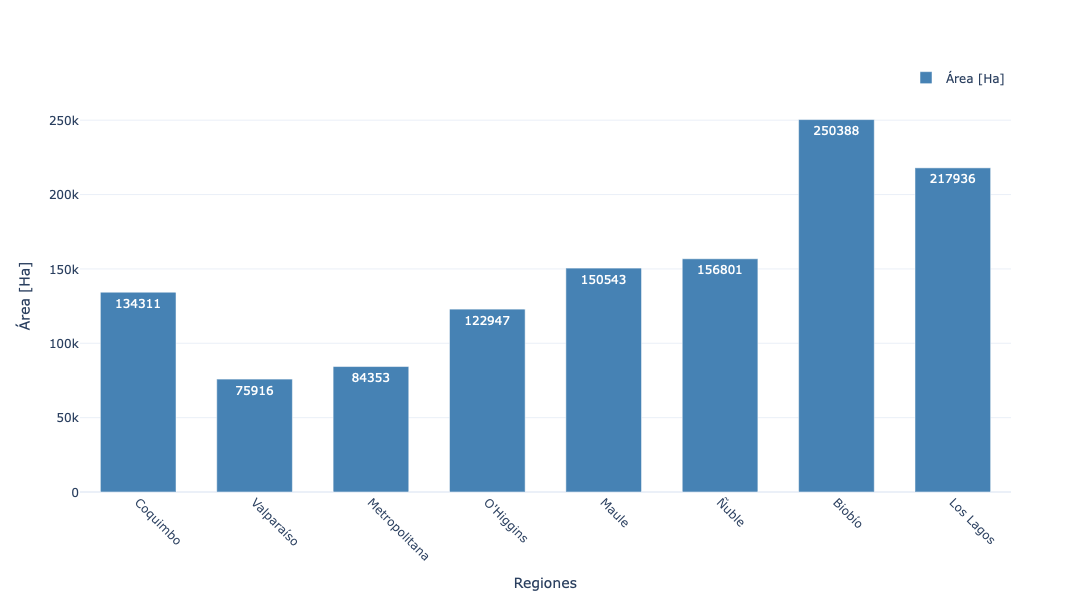

In [18]:
position = np.arange(len(data_region_ch))

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=position,
        y=data_region_ch["ha"],
        name="Área [Ha]",
        marker_color="steelblue",
        text=data_region_ch["ha"].round(2),  # Show values on hover
        hovertemplate="Región: %{x}<br>Área: %{y:.2f} Ha<extra></extra>"
    )
)

# Update layout
fig.update_layout(
    width=800,
    height=600,
    template="plotly_white",
    xaxis=dict(
        title="Regiones",
        tickvals=position,
        ticktext=data_region_ch["Region"],
        tickangle=45
    ),
    yaxis=dict(
        title="Área [Ha]"
    ),
    bargap=0.35,  # equivalent to width parameter
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

In [19]:
data_time_ch = data_ch.groupby('Year')['ha'].sum().reset_index()
data_time_ch['ha (cumulative)'] = data_time_ch['ha'].cumsum()
data_time_ch["Year"] = data_time_ch["Year"].astype(int)
data_time_ch

,Year,ha,ha (cumulative)
0,2008,57936,57936
1,2014,84353,142289
2,2017,160000,302289
3,2018,36956,339245
4,2021,26000,365245
5,2023,713750,1078995
6,2024,112200,1191195
7,2025,2000,1193195


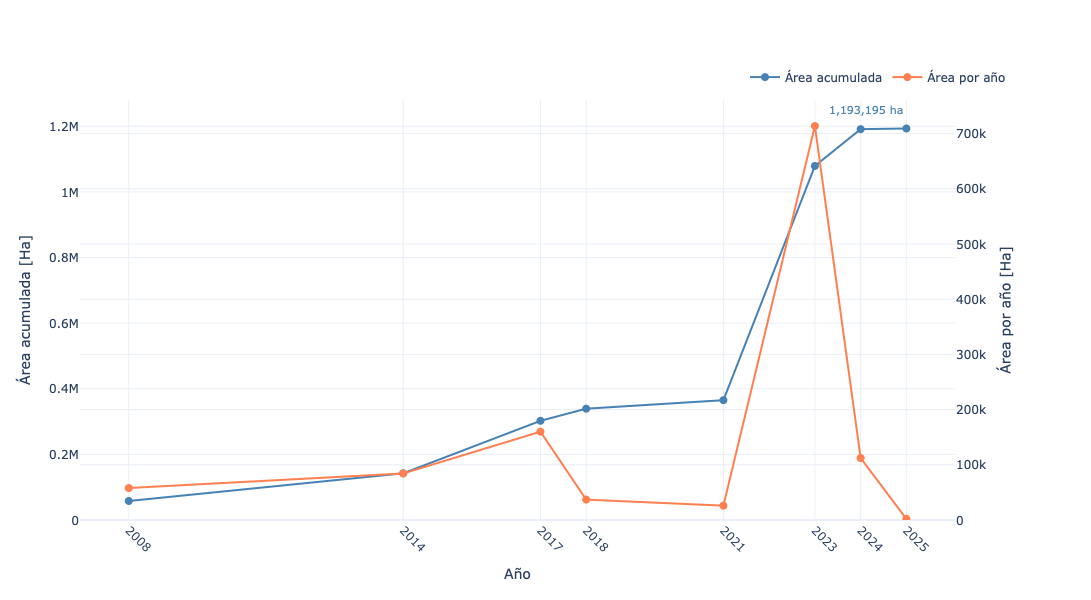

In [20]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add cumulative area line
fig.add_trace(
    go.Scatter(
        x=data_time_ch["Year"],
        y=data_time_ch["ha (cumulative)"],
        mode='lines+markers',
        name="Área acumulada",
        line=dict(color="steelblue", width=2),
        marker=dict(size=8),
        hovertemplate="Año: %{x}<br>Área acumulada: %{y:,.0f} Ha<extra></extra>"
    ),
    secondary_y=False
)

# Add annotation for specific cumulative value
fig.add_annotation(
    x=data_time_ch["Year"].iloc[7],
    y=data_time_ch["ha (cumulative)"].iloc[7],
    text=f'{data_time_ch["ha (cumulative)"].iloc[7]:,.0f} ha',
    showarrow=False,
    xshift=-40,
    yshift=20,
    font=dict(color="steelblue", size=11)
)

# Add annual area line
fig.add_trace(
    go.Scatter(
        x=data_time_ch["Year"],
        y=data_time_ch["ha"],
        mode='lines+markers',
        name="Área por año",
        line=dict(color="coral", width=2),
        marker=dict(size=8),
        hovertemplate="Año: %{x}<br>Área anual: %{y:,.0f} Ha<extra></extra>"
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    width=800,
    height=600,
    template="plotly_white",
    hovermode='x unified',
    xaxis=dict(
        title="Año",
        tickvals=data_time_ch["Year"],
        ticktext=data_time_ch["Year"],
        tickangle=45
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Update y-axes
fig.update_yaxes(
    title_text="Área acumulada [Ha]",
    secondary_y=False,
    rangemode="nonnegative"  # equivalent to ylim(0)
)

fig.update_yaxes(
    title_text="Área por año [Ha]",
    secondary_y=True,
    rangemode="nonnegative"
)

fig.show()